# Structure Learning for MNIST with a Renormalising Generative Model

Strongly inspired by (but not a direct reproduction of) Friston et al. (2025) *From pixels to planning: scale-free active inference.* Front. Netw. Physiol. 5:1521963

In [7]:
from utils import load_mnist

x_train, y_train, x_test, y_test = load_mnist()


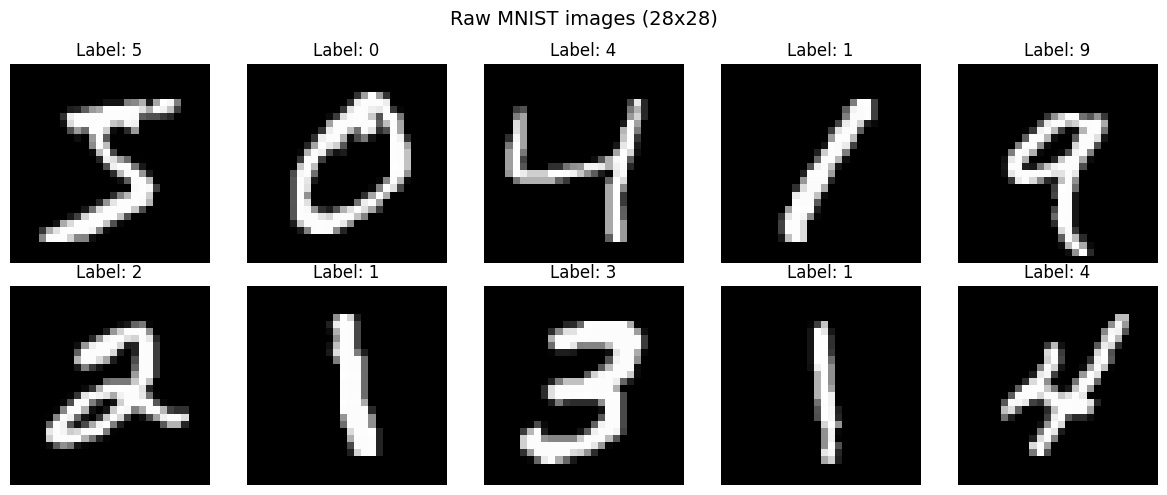

In [8]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')

fig.suptitle('Raw MNIST images (28x28)', fontsize=14)
plt.tight_layout()
plt.show()

## Select Structure Learning Exemplars
From the paper (p.10):

> Based on the prior that there can be a dozen ways of writing any given number, the first 13 (Baker's dozen) images of each digit class were used for fast structure learning.

These 130 images (13 per class x 10 classes) are used to build the initial RGM hierarchy via fast structure learning. The remaining images are used for active learning.

In [9]:
import jax
from jax import numpy as jnp

In [10]:
from utils import extract_exemplars

M_PER_CLASS = 13  # Baker's dozen
NUM_CLASSES = 10

x_exemplars_raw, y_exemplars, exemplar_idx = extract_exemplars(x_train, y_train, M_PER_CLASS, NUM_CLASSES)
print(f"Exemplar images: {x_exemplars_raw.shape}")
print(f"Per class: {[(y_exemplars == d).sum().item() for d in range(10)]}")

Exemplar images: (130, 28, 28)
Per class: [13, 13, 13, 13, 13, 13, 13, 13, 13, 13]


In [11]:
from preprocess import preprocess

x_exemplars = preprocess(x_exemplars_raw)
print(f"Preprocessed exemplars: {x_exemplars.shape}")

Preprocessed exemplars: (130, 32, 32)


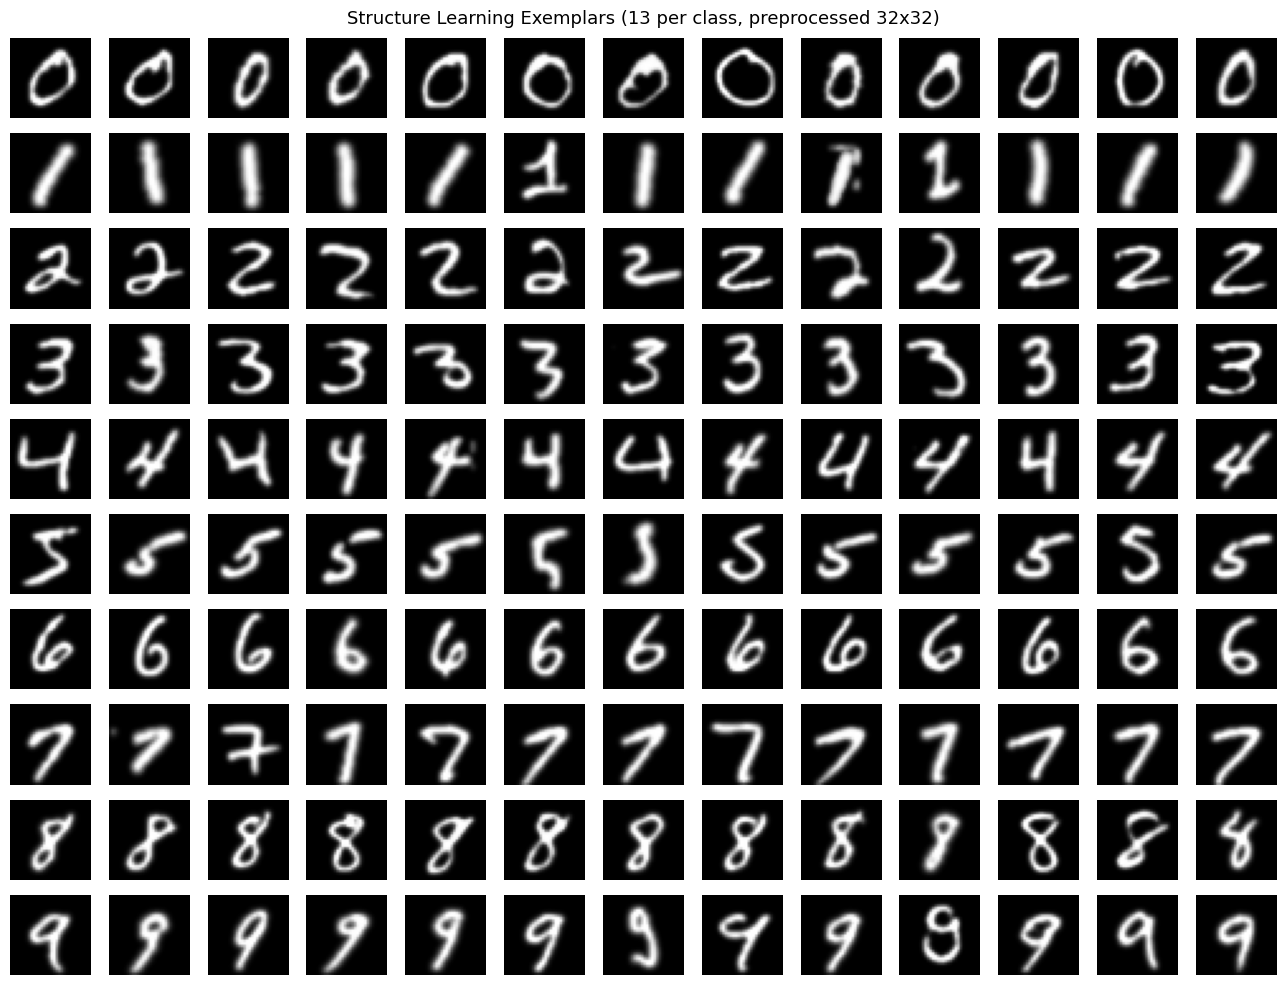

In [12]:
fig, axes = plt.subplots(NUM_CLASSES, M_PER_CLASS, figsize=(M_PER_CLASS, NUM_CLASSES))
for digit in range(NUM_CLASSES):
    mask = y_exemplars == digit
    digit_imgs = x_exemplars[mask]
    for j in range(M_PER_CLASS):
        axes[digit, j].imshow(digit_imgs[j], cmap='gray')
        axes[digit, j].axis('off')
    axes[digit, 0].set_ylabel(str(digit), rotation=0, fontsize=12, labelpad=15)
fig.suptitle(f'Structure Learning Exemplars ({M_PER_CLASS} per class, preprocessed 32x32)', fontsize=13)
plt.tight_layout()
plt.show()

## Discretisation using Singular Value Decomposition (SVD)

From the paper (p.8-10): Images are tessellated into 4x4 patches. Each patch location gets its own SVD basis learned from the structure exemplars. Continuous singular variates are quantised into 7 discrete levels, producing a discrete observation tensor per image.

The main text in the paper says:

> "Each group is then subject to singular value decomposition, given a training set of images, to identify an orthogonal (spatial) basis set of singular vectors. This grouping is followed by a reduction operator that retains singular variates with large singular values (here, the first 32 principal vectors based on groups of 4 × 4 pixels)."

> "The set of singular variates for each group specifies the pattern for any given image at the corresponding location. The continuous variates can then be quantized to a discrete number of levels (here, seven)."

However the figure 4 caption says:

> "...in this example, the singular variates could take seven discrete values centered on zero for a maximum of 16 singular vectors."

And footnote 7 says:

> "In practice, we use overlapping groups, where the singular value decomposition is applied following weighting by a radial (Gaussian) basis function whose standard deviation is the distance between group centers."

SPM alignment notes:

- SVD modes are selected adaptively via spm_svd(Y, 1/su) where su=8, retaining only modes with normalized singular values above 1/su. This is capped at mm=16 max modes.
- Bin assignment uses nearest-centre (not edge-based) matching SPM's [~, U] = min(abs(u(t,m) - a)).
- The number of retained modes varies per patch location.

Here we will use overlapping groups, as that seems sensible given the discussion points about receptive fields later in the paper. 

In [13]:
from discretise import (
    DiscretiseConfig,
    compute_svd_basis_overlapping, 
    encode_images_overlapping, 
    decode_observations_overlapping,
)

config = DiscretiseConfig()

basis = compute_svd_basis_overlapping(x_exemplars, config)
obs = encode_images_overlapping(x_exemplars, basis)
recon = decode_observations_overlapping(obs, basis)

print(f"  V shape:       {basis.V.shape}")
print(f"  Modes/patch:   min={int(basis.n_modes.min())}, max={int(basis.n_modes.max())}, mean={float(basis.n_modes.mean()):.1f}")
print(f"  MSE:           {float(((x_exemplars - recon[:, 0]) ** 2).mean()):.2f}")

  V shape:       (8, 8, 1024, 16)
  Modes/patch:   min=3, max=9, mean=6.6
  MSE:           127.29


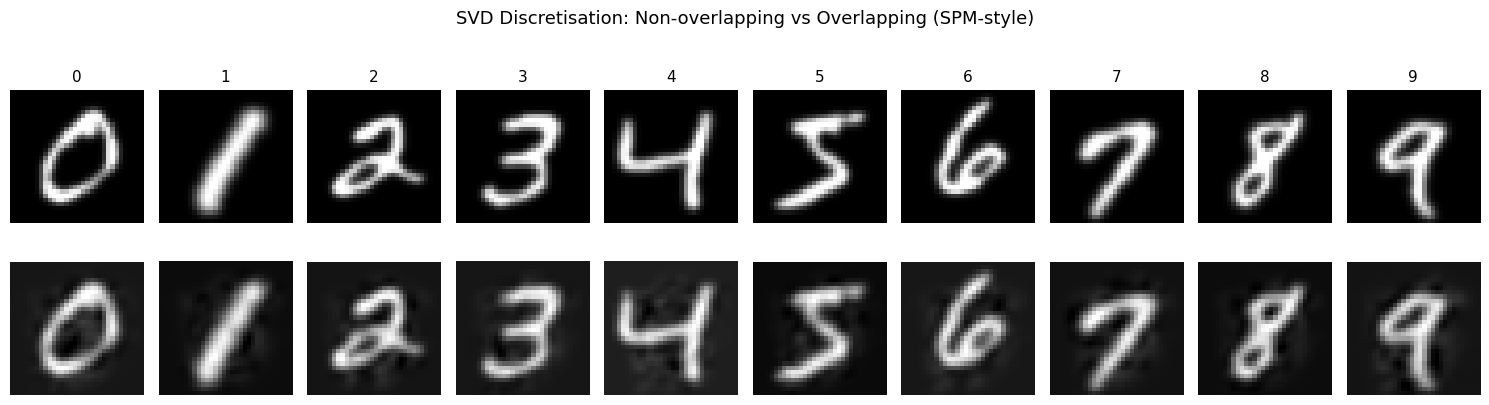

In [ ]:
# Show impact of discretisation on information loss

show_idx = [jnp.where(y_exemplars == d)[0][0].item() for d in range(NUM_CLASSES)]

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 1.5, 4.5))
for col, idx in enumerate(show_idx):
    axes[0, col].imshow(x_exemplars[idx], cmap='gray')
    axes[0, col].set_title(str(col), fontsize=11)
    axes[0, col].axis('off')
    axes[1, col].imshow(recon[idx, 0], cmap='gray')
    axes[1, col].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Overlapping', fontsize=11)
fig.suptitle('SVD Discretisation and Reconstruction', fontsize=13)
plt.tight_layout()
plt.show()